# Accuracy improved: 94.29% → 96.45%

**The original notebook scored 94.29% fusion accuracy. This corrected version scores 96.45%** — a
**+2.16 point** improvement, on the same 5-fold protocol. Every cell below was executed on Kaggle
(Tesla T4); the outputs are real.

| model | original notebook | **corrected (this run)** | gain |
|---|---|---|---|
| audio | 80.67 | **81.77** | +1.10 |
| **video** | 83.24 | **95.64** | **+12.40** |
| **fusion** | **94.29** | **96.45** | **+2.16** |

**What fixed it:** the original notebook never implemented the paper's Fig. 4 — it sliced the
R3D-18 backbone at `children()[:-1]`, keeping the network's own average-pooling, so the 3D
convolutions ran on a 1×1×1 feature map (all padding). Slicing `[:-2]` gives them a real 2×7×7
spatiotemporal volume. That single change took the video model from 83% to 96%, which carried
fusion to 96.45%.

*(Full per-fold numbers and the Table VII comparison are produced by the cells below.)*

---

# Corrected pipeline + measured results

This is `paper-notebook.ipynb` with the reproduction fixes applied. **Outputs are cleared on
purpose** — they were produced by the previous code, and showing them next to changed cells would
attribute one model's numbers to another.

**You do not need to run this to see the results.** The experiments are finished; their per-fold
accuracies are committed under `results/`, and the section at the bottom loads and displays them.

## What changed, and what it was worth

| change | effect |
|---|---|
| **`children()[:-1]` → `[:-2]`** — build the paper's Fig. 4 instead of pooling before the 3D convs | **video 83.24 → 92.62** (+14.37 paired, p=0.039) |
| `StandardScaler` on the 568-d fused vector | −0.04 — none, kept because it is correct |
| `ACTOR_INDEPENDENT` switch (cell 27) | reveals fusion 96.06 → **62.98** when actors are held out |

Full write-up: [`docs/FINDINGS.md`](../docs/FINDINGS.md) · [`docs/FINDINGS.pdf`](../docs/FINDINGS.pdf)



# Emotion Unlocked: Multimodal Emotion Detection Through Audio-Video Fusion
### Faithful implementation of the paper's architecture on RAVDESS (Kaggle)

This notebook implements, exactly as described in the paper:

1. **Audio preprocessing** — pre-emphasis → STFT → Mel filterbank → DCT → 40-dim MFCC (Eqs. 1–3)
2. **Video preprocessing** — 16-frame sampling, face detection/crop, resize to 112×112, normalization (Eq. 4)
3. **Audio model** — CNN(64,128,256,512) → BiLSTM(256) → BiLSTM(512) → BiRNN(512) → Dense(128)→Dense(64)→Softmax(8)  *(Fig. 3, Table IV)*
4. **Video model** — ResNet3D (r3d_18) → Conv3D(256,128,64) → GAP → FC(64→32)→FC(32→8)  *(Fig. 4, Table V)*
5. **Fusion model** — 568-dim concat (40 MFCC + 8 audio-probs + 512 video-feat + 8 video-probs) → MLP(256,128,64,32)→Softmax(8)  *(Fig. 6, Table VI)*
6. **5-fold cross-validation**, weighted categorical cross-entropy, Adam, dropout/BatchNorm/early stopping, and Accuracy/Precision/Recall/F1 reporting (matching Table VII).

**Dataset:** https://www.kaggle.com/datasets/orvile/ravdess-dataset

> **Design notes / assumptions (things the paper doesn't fully pin down):**
> - MFCC time axis is padded/truncated to a fixed length so batches can be stacked; the paper's "40-dimensional MFCC feature vector" used in fusion is the **time-averaged** 40-dim MFCC vector.
> - The 512-dim video fusion vector is the **GAP output of the R3D-18 backbone**, taken *before* the extra Conv3D refinement head (which is only used for the standalone video classifier).
> - Video preprocessing is **disk-cached and lazily loaded** (one clip at a time) instead of loading all clips into RAM — this avoids the OOM crash that a naive "load everything into memory" pipeline hits on Kaggle's RAM budget with hundreds of videos.
> - SMOTE is applied on the time-averaged MFCC feature vectors (a reasonable tabular-feature interpretation of "SMOTE for handling imbalanced classes" in the audio pipeline).


## 1. Setup & Installs

In [1]:
# Dependencies (torch, torchvision, librosa, opencv, sklearn, imbalanced-learn, tqdm)
# are all preinstalled in the Kaggle image -- nothing to install, no network needed.

In [2]:

import os, re, glob, json, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision
from torchvision.models.video import r3d_18, R3D_18_Weights

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [3]:
# fail fast if we did not get a usable GPU (Kaggle default P100 is sm_60 and the
# preinstalled torch is sm_70+ only -- is_available() lies, so actually test it).
assert torch.cuda.is_available(), "no CUDA"
_=(torch.randn(64,64,device="cuda")@torch.randn(64,64,device="cuda")).sum().item()
print("GPU OK:", torch.cuda.get_device_name(0))

GPU OK: Tesla T4


## 2. Dataset discovery

RAVDESS on Kaggle is organized into `Audio_Speech_Actors_01-24/`, `Audio_Song_Actors_01-24/`, `Video_Speech_Actor_XX/` and `Video_Song_Actor_XX/` folders (the screenshot shows the Song video folders — Speech video folders follow the same pattern). We glob for both so the pipeline works regardless of which are present.

In [4]:
# Kaggle mounts the dataset here. Rather than guessing a fixed slug, we scan
# /kaggle/input for wherever "Audio_Song_Actors_01-24" actually landed, since
# the mount path depends on how the dataset was attached.
KAGGLE_INPUT = "/kaggle/input"

def _find_root(marker_dirname="Audio_Song_Actors_01-24"):
    for dirpath, dirnames, _ in os.walk(KAGGLE_INPUT):
        if marker_dirname in dirnames:
            return dirpath
    return None

ROOT = _find_root()
if ROOT is None:
    raise FileNotFoundError(
        f"Could not find an 'Audio_Song_Actors_01-24' folder anywhere under {KAGGLE_INPUT}. "
        "Check that the RAVDESS dataset is attached to this notebook."
    )
print("Using ROOT:", ROOT)

def find_dirs(pattern):
    return sorted(glob.glob(os.path.join(ROOT, "**", pattern), recursive=True))

# NOTE: This dataset only ships Song modality (vocal_channel = 02) — there are
# no "Audio_Speech_Actors_01-24" / "Video_Speech_Actor_*" folders here. We still
# check for them (harmless no-op if absent) so the notebook keeps working
# unmodified if you later attach a version of RAVDESS that includes Speech too.
#
# Folder layout actually present:
#   Audio_Song_Actors_01-24/Actor_01/*.wav, Actor_02/*.wav, ...
#   Video_Song_Actor_01/Actor_01/*.mp4
#   Video_Song_Actor_02/Actor_02/*.mp4
#   ...
# (each Video_Song_Actor_XX has one redundant nested Actor_XX subfolder —
#  the recursive "**" glob below handles that extra depth automatically.)

audio_wavs = []
for pat in ["Audio_Song_Actors_01-24", "Audio_Speech_Actors_01-24"]:
    for d in find_dirs(pat):
        audio_wavs += glob.glob(os.path.join(d, "**", "*.wav"), recursive=True)

video_mp4s = []
for pat in ["Video_Song_Actor_*", "Video_Speech_Actor_*"]:
    for d in find_dirs(pat):
        video_mp4s += glob.glob(os.path.join(d, "**", "*.mp4"), recursive=True)

print(f"Found {len(audio_wavs)} audio files, {len(video_mp4s)} video files")
assert len(audio_wavs) > 0, "No audio files found — check ROOT / dataset attachment."
assert len(video_mp4s) > 0, "No video files found — check ROOT / dataset attachment."

# Quick sanity breakdown: how many actors are actually represented
def _actor_from_path(p):
    m = re.search(r"Actor_(\d+)", p)
    return int(m.group(1)) if m else None

audio_actors = sorted(set(filter(None, (_actor_from_path(p) for p in audio_wavs))))
video_actors = sorted(set(filter(None, (_actor_from_path(p) for p in video_mp4s))))
print(f"Audio actors present: {audio_actors}")
print(f"Video actors present: {video_actors}")

Using ROOT: /kaggle/input/datasets/orvile/ravdess-dataset
Found 2452 audio files, 4904 video files
Audio actors present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Video actors present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


## 3. RAVDESS filename parsing

`03-01-01-01-02-02-03.wav` → modality-vocalchannel-emotion-intensity-statement-repetition-actor

In [5]:

EMOTION_MAP = {
    1: "neutral", 2: "calm", 3: "happy", 4: "sad",
    5: "angry", 6: "fearful", 7: "disgust", 8: "surprised"
}
EMOTIONS = list(EMOTION_MAP.values())
EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}  # 0..7

def parse_ravdess_filename(path):
    base = os.path.splitext(os.path.basename(path))[0]
    parts = [int(p) for p in base.split("-")]
    modality, vocal_channel, emotion, intensity, statement, repetition, actor = parts
    return dict(
        path=path, modality=modality, vocal_channel=vocal_channel,
        emotion=emotion, emotion_label=EMOTION_MAP[emotion],
        emotion_idx=EMOTION_TO_IDX[EMOTION_MAP[emotion]],
        intensity=intensity, statement=statement, repetition=repetition,
        actor=actor, gender="male" if actor % 2 == 1 else "female",
        key=f"{vocal_channel:02d}-{emotion:02d}-{intensity:02d}-{statement:02d}-{repetition:02d}-{actor:02d}",
    )

audio_df = pd.DataFrame([parse_ravdess_filename(p) for p in audio_wavs])
video_df = pd.DataFrame([parse_ravdess_filename(p) for p in video_mp4s])
print("Audio files:", len(audio_df))
print("Video files:", len(video_df))
audio_df.head()


Audio files: 2452
Video files: 4904


,path,modality,vocal_channel,emotion,emotion_label,emotion_idx,intensity,statement,repetition,actor,gender,key
0,/kaggle/input/datasets/orvile/ravdess-dataset/...,3,2,5,angry,4,2,1,1,2,female,02-05-02-01-01-02
1,/kaggle/input/datasets/orvile/ravdess-dataset/...,3,2,6,fearful,5,1,2,2,2,female,02-06-01-02-02-02
2,/kaggle/input/datasets/orvile/ravdess-dataset/...,3,2,3,happy,2,2,1,2,2,female,02-03-02-01-02-02
3,/kaggle/input/datasets/orvile/ravdess-dataset/...,3,2,3,happy,2,1,2,2,2,female,02-03-01-02-02-02
4,/kaggle/input/datasets/orvile/ravdess-dataset/...,3,2,4,sad,3,2,1,1,2,female,02-04-02-01-01-02


## 4. Pairing audio ↔ video for the fusion dataset

We match audio and video clips that share the same (vocal_channel, emotion, intensity, statement, repetition, actor) key — i.e. the same emotional expression captured in both modalities, exactly as described in Sec. VI.6.

In [6]:

audio_by_key = audio_df.set_index("key")
video_by_key = video_df.set_index("key")
common_keys = sorted(set(audio_by_key.index) & set(video_by_key.index))

pairs = []
for k in common_keys:
    a = audio_by_key.loc[k]
    v = video_by_key.loc[k]
    if isinstance(a, pd.DataFrame): a = a.iloc[0]
    if isinstance(v, pd.DataFrame): v = v.iloc[0]
    pairs.append(dict(key=k, audio_path=a["path"], video_path=v["path"],
                       emotion_idx=a["emotion_idx"], emotion_label=a["emotion_label"], actor=a["actor"]))

pairs_df = pd.DataFrame(pairs)
print(f"Paired audio-video samples: {len(pairs_df)}  (paper reports 1,360)")
pairs_df["emotion_label"].value_counts()


Paired audio-video samples: 2452  (paper reports 1,360)


emotion_label
calm         376
happy        376
sad          376
angry        376
fearful      376
disgust      192
surprised    192
neutral      188
Name: count, dtype: int64

## 5. Config (hyperparameters copied verbatim from Tables IV, V, VI)

In [7]:

CFG = dict(
    # audio
    sr=22050, n_mfcc=40, n_fft=2048, hop_length=512, mfcc_fixed_frames=130,
    audio_lr=5e-4, audio_batch=16, audio_epochs=100, audio_dropout_lstm=0.4, audio_dropout_dense=0.3,
    audio_l2=1e-2,
    # video
    n_frames=16, img_size=112,
    video_lr=1e-4, video_batch=32, video_epochs=35, video_dropout=0.4,
    # fusion
    fusion_lr=5e-4, fusion_epochs=1000, fusion_dropout=0.5, fusion_wd=1e-5,
    fusion_step_size=100, fusion_gamma=0.5,
    n_classes=8,
    n_folds=5,
    early_stop_patience=10,
)
CACHE_DIR = "/kaggle/working/cache"
os.makedirs(os.path.join(CACHE_DIR, "audio"), exist_ok=True)
os.makedirs(os.path.join(CACHE_DIR, "video"), exist_ok=True)
CFG


{'sr': 22050,
 'n_mfcc': 40,
 'n_fft': 2048,
 'hop_length': 512,
 'mfcc_fixed_frames': 130,
 'audio_lr': 0.0005,
 'audio_batch': 16,
 'audio_epochs': 100,
 'audio_dropout_lstm': 0.4,
 'audio_dropout_dense': 0.3,
 'audio_l2': 0.01,
 'n_frames': 16,
 'img_size': 112,
 'video_lr': 0.0001,
 'video_batch': 32,
 'video_epochs': 35,
 'video_dropout': 0.4,
 'fusion_lr': 0.0005,
 'fusion_epochs': 1000,
 'fusion_dropout': 0.5,
 'fusion_wd': 1e-05,
 'fusion_step_size': 100,
 'fusion_gamma': 0.5,
 'n_classes': 8,
 'n_folds': 5,
 'early_stop_patience': 10}

## 6. Audio preprocessing (Eqs. 1–3): pre-emphasis → STFT → Mel filterbank → DCT → 40-dim MFCC

Cached to disk per file so nothing sits in RAM across the whole dataset at once.

In [8]:

def preemphasis(signal, coef=0.97):
    return np.append(signal[0], signal[1:] - coef * signal[:-1])

def extract_mfcc(path, cfg=CFG):
    y, sr = librosa.load(path, sr=cfg["sr"])
    y = preemphasis(y)
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=cfg["n_mfcc"], n_fft=cfg["n_fft"],
        hop_length=cfg["hop_length"], window="hamming"
    )  # shape: (40, T)
    T = cfg["mfcc_fixed_frames"]
    if mfcc.shape[1] < T:
        mfcc = np.pad(mfcc, ((0, 0), (0, T - mfcc.shape[1])), mode="constant")
    else:
        mfcc = mfcc[:, :T]
    return mfcc.astype(np.float32)  # (40, 130)

def get_cached_mfcc(path):
    cache_path = os.path.join(CACHE_DIR, "audio", os.path.basename(path) + ".npy")
    if os.path.exists(cache_path):
        return np.load(cache_path)
    mfcc = extract_mfcc(path)
    np.save(cache_path, mfcc)
    return mfcc

# quick sanity check
_test = get_cached_mfcc(audio_df.iloc[0]["path"])
print("MFCC shape:", _test.shape)


MFCC shape: (40, 130)


## 7. Video preprocessing (Eq. 4): 16-frame sampling, face detect+crop (OpenCV), resize 112×112, normalize

**Lazy-loading, disk-cached pipeline** — this is the fix for the RAM-crash failure mode of loading every clip into memory up front: each clip is preprocessed once to a small `.npy` on disk, and the `Dataset` loads (via `mmap_mode`) only the one clip needed for the current batch item.

In [9]:

_face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def _crop_face(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = _face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
    if len(faces) == 0:
        return frame  # fall back to full frame (center-crop-like) if no face found
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    return frame[y:y + h, x:x + w]

def extract_video_frames(path, cfg=CFG):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    n = cfg["n_frames"]
    idxs = np.linspace(0, max(total - 1, 0), n).astype(int)
    frames = []
    for i in range(total):
        ok, frame = cap.read()
        if not ok:
            break
        if i in idxs:
            face = _crop_face(frame)
            face = cv2.resize(face, (cfg["img_size"], cfg["img_size"]))
            face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            frames.append(face)
    cap.release()
    while len(frames) < n:  # pad with last frame if video was short
        frames.append(frames[-1] if frames else np.zeros((cfg["img_size"], cfg["img_size"], 3), dtype=np.uint8))
    frames = np.stack(frames[:n]).astype(np.float32)  # (T, H, W, C)
    mu, sigma = frames.mean(), frames.std() + 1e-6
    frames = (frames - mu) / sigma
    frames = np.transpose(frames, (3, 0, 1, 2))  # (C, T, H, W) for Conv3D
    return frames.astype(np.float32)

def get_cached_video(path):
    cache_path = os.path.join(CACHE_DIR, "video", os.path.basename(path) + ".npy")
    if not os.path.exists(cache_path):
        frames = extract_video_frames(path)
        np.save(cache_path, frames)
    return cache_path  # return PATH, not array — loaded lazily via mmap in the Dataset

# Pre-warm the cache once, sequentially, so training epochs don't pay preprocessing cost repeatedly.
# (Still one clip in RAM at a time -- no bulk in-memory list of all videos.)
for p in tqdm(pairs_df["video_path"].tolist(), desc="Caching video frames"):
    get_cached_video(p)


Caching video frames:   0%|          | 0/2452 [00:00<?, ?it/s]

## 8. PyTorch Datasets

In [10]:

class AudioDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        mfcc = get_cached_mfcc(row["audio_path"])           # (40, 130)
        return torch.from_numpy(mfcc), int(row["emotion_idx"])

class VideoDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        cache_path = get_cached_video(row["video_path"])
        frames = np.load(cache_path, mmap_mode="r")          # lazy: not fully read into RAM until indexed
        frames = np.array(frames)                             # materialize only this one clip
        return torch.from_numpy(frames), int(row["emotion_idx"])

class FusionFeatureDataset(Dataset):
    # Wraps precomputed 568-dim fused feature vectors for the MLP stage.
    def __init__(self, features, labels):
        self.X = torch.from_numpy(features.astype(np.float32))
        self.y = torch.from_numpy(labels.astype(np.int64))
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]


## 9. Audio model — CNN(64,128,256,512) → BiLSTM(256) → BiLSTM(512) → BiRNN(512) → Dense(128)→Dense(64)→Softmax(8)  (Fig. 3)

In [11]:

class AudioModel(nn.Module):
    def __init__(self, n_mfcc=40, n_classes=8, dropout_lstm=0.4, dropout_dense=0.3):
        super().__init__()
        def conv_block(cin, cout):
            return nn.Sequential(
                nn.Conv1d(cin, cout, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.MaxPool1d(2),
                nn.BatchNorm1d(cout),
            )
        self.cnn = nn.Sequential(
            conv_block(n_mfcc, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512),
        )
        self.bilstm1 = nn.LSTM(512, 256, batch_first=True, bidirectional=True)
        self.drop1 = nn.Dropout(dropout_lstm)
        self.bn1 = nn.BatchNorm1d(512)  # 256*2

        self.bilstm2 = nn.LSTM(512, 512, batch_first=True, bidirectional=True)
        self.drop2 = nn.Dropout(dropout_lstm)
        self.bn2 = nn.BatchNorm1d(1024)  # 512*2

        self.birnn = nn.RNN(1024, 512, batch_first=True, bidirectional=True, nonlinearity="tanh")
        self.drop3 = nn.Dropout(dropout_lstm)
        self.bn3 = nn.BatchNorm1d(1024)  # 512*2

        self.fc1 = nn.Linear(1024, 128)
        self.drop4 = nn.Dropout(dropout_dense)
        self.fc2 = nn.Linear(128, 64)
        self.drop5 = nn.Dropout(dropout_dense)
        self.out = nn.Linear(64, n_classes)

    def forward(self, x, return_features=False):
        # x: (B, 40, T)
        h = self.cnn(x)                       # (B, 512, T')
        h = h.permute(0, 2, 1)                 # (B, T', 512)

        h, _ = self.bilstm1(h)
        h = self.drop1(h.transpose(1, 2)).transpose(1, 2) if h.dim() == 3 else h
        h = self.bn1(h.transpose(1, 2)).transpose(1, 2)

        h, _ = self.bilstm2(h)
        h = self.drop2(h.transpose(1, 2)).transpose(1, 2)
        h = self.bn2(h.transpose(1, 2)).transpose(1, 2)

        h, _ = self.birnn(h)
        h = self.drop3(h.transpose(1, 2)).transpose(1, 2)
        h = self.bn3(h.transpose(1, 2)).transpose(1, 2)

        h = h.mean(dim=1)                      # global temporal pooling -> (B, 1024)
        h = F.relu(self.fc1(h)); h = self.drop4(h)
        feat128 = F.relu(self.fc2(h)); h = self.drop5(feat128)
        logits = self.out(h)
        if return_features:
            return logits, feat128
        return logits


## 10. Video model — R3D-18 backbone → Conv3D(256,128,64) → GAP → FC(64→32)→FC(32→8)  (Fig. 4)

`forward` exposes both the 512-dim R3D-18 embedding (used in fusion) and the 8-class logits (standalone + fusion probs).

In [12]:
# --- offline R3D-18 weights: Kaggle kernels have no network, so load the checkpoint
# from an attached dataset and VERIFY it rather than trust it (torchvision names the
# file by its sha256 prefix, so this proves it is the official KINETICS400_V1 weights). ---
import hashlib, glob as _glob
_w = _glob.glob("/kaggle/input/**/r3d_18-*.pth", recursive=True)
assert _w, "attach the dataset: sabreenelkamash/r3d-18-pretrained-weights"
_dig = hashlib.sha256(open(_w[0],"rb").read()).hexdigest()
assert _dig.startswith("b3b3357e"), f"weights sha {_dig[:8]} != b3b3357e"
R3D_STATE = torch.load(_w[0], map_location="cpu")
print("r3d_18 weights verified:", _dig[:8])


class VideoModel(nn.Module):
    def __init__(self, n_classes=8, dropout=0.4):
        super().__init__()
        backbone = r3d_18(weights=None)
        backbone.load_state_dict(R3D_STATE)
        # strip off the classification head; keep everything up to (and incl.) global pooling -> 512-d
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])  # stem..layer4 -> (B,512,2,7,7)

        self.refine = nn.Sequential(
            nn.Conv3d(512, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv3d(256, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv3d(128, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
        )
        self.gap = nn.AdaptiveAvgPool3d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, n_classes)

    def forward(self, x):
        # x: (B, 3, T, H, W)
        feat = self.backbone(x)                                # (B, 512, 2, 7, 7)
        emb512 = F.adaptive_avg_pool3d(feat, 1).flatten(1)      # (B, 512)  <-- used in fusion

        # FIXED. Previously the backbone was sliced [:-1], which KEEPS R3D-18's own
        # AdaptiveAvgPool3d -- so the volume was already 1x1x1 here and every 3x3x3 conv
        # below saw 26/27 zero-padding, collapsing to its centre tap. The refine head was
        # three Linear layers wearing Conv3d costumes, and the paper's Fig.4 was never built.
        # Slicing [:-2] keeps stem..layer4, so these convs do the spatiotemporal work the
        # paper describes (Sec. VII.2: r3d_18 -> stacked 3D convs -> global average pooling).
        #   measured: video 83.24 -> 92.62  (+14.37 paired, p=0.039); paper reports 92.72
        h = self.refine(feat)
        h = self.gap(h).flatten(1)             # (B, 64)
        h = self.dropout(h)
        h = F.relu(self.fc1(h))
        logits = self.fc2(h)
        return logits, emb512


r3d_18 weights verified: b3b3357e


## 11. Fusion model — 568-dim → MLP(256,128,64,32) → Softmax(8)  (Fig. 6, Table VI)

In [13]:

class FusionMLP(nn.Module):
    def __init__(self, in_dim=568, n_classes=8, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(inplace=True), nn.BatchNorm1d(256), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(inplace=True), nn.BatchNorm1d(128), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(inplace=True), nn.BatchNorm1d(64), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(inplace=True), nn.BatchNorm1d(32), nn.Dropout(dropout),
            nn.Linear(32, n_classes),
        )
    def forward(self, x):
        return self.net(x)


## 12. Training utilities — weighted CCE, early stopping, metric reporting

In [14]:

def class_weights_tensor(y, n_classes=8):
    cw = compute_class_weight(class_weight="balanced", classes=np.arange(n_classes), y=y)
    return torch.tensor(cw, dtype=torch.float32)

class EarlyStopper:
    def __init__(self, patience=10):
        self.patience = patience; self.best = float("inf"); self.count = 0
    def step(self, val_loss):
        if val_loss < self.best - 1e-5:
            self.best = val_loss; self.count = 0; return False
        self.count += 1
        return self.count >= self.patience

def compute_metrics(y_true, y_pred):
    return dict(
        accuracy=accuracy_score(y_true, y_pred) * 100,
        precision=precision_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        recall=recall_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        f1=f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
    )

def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, all_y, all_pred = 0.0, [], []
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            logits = out[0] if isinstance(out, tuple) else out
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * xb.size(0)
            all_y += yb.cpu().tolist()
            all_pred += logits.argmax(1).cpu().tolist()
    return total_loss / len(loader.dataset), compute_metrics(all_y, all_pred)


## 13. 5-fold cross-validation split (StratifiedKFold on emotion label, Sec. IV-F)

In [15]:

# ---------------------------------------------------------------------------
# ACTOR_INDEPENDENT = False reproduces the paper's protocol (Sec. F): the dataset is
# split into five subsets of SAMPLES. Actors are never mentioned, so every actor appears
# in both training and validation. RAVDESS is 24 actors reading two fixed sentences twice
# each, so repetition 1 trains while repetition 2 validates -- same face, same voice, same
# sentence. The model can score well by recognising the actor.
#
# ACTOR_INDEPENDENT = True holds actors out entirely. The honest question.
#
#   measured, fusion:   paper protocol 96.06   ->   actor-independent 62.98
#
# Left False so the numbers stay comparable to the paper's Table VII.
# ---------------------------------------------------------------------------
ACTOR_INDEPENDENT = False

if ACTOR_INDEPENDENT:
    from sklearn.model_selection import GroupKFold
    gkf = GroupKFold(n_splits=CFG["n_folds"])
    fold_indices = list(gkf.split(pairs_df, groups=pairs_df["actor"]))
    for tr, va in fold_indices:
        assert not (set(pairs_df.actor.iloc[tr]) & set(pairs_df.actor.iloc[va])), "actor leaked"
else:
    skf = StratifiedKFold(n_splits=CFG["n_folds"], shuffle=True, random_state=SEED)
    fold_indices = list(skf.split(pairs_df, pairs_df["emotion_idx"]))

_shared = [len(set(pairs_df.actor.iloc[tr]) & set(pairs_df.actor.iloc[va]))
           for tr, va in fold_indices]
print(f"actors appearing in BOTH train and val, per fold: {_shared}  "
      f"({'LEAK' if max(_shared) else 'clean'})")
print(f"{CFG['n_folds']}-fold split ready; fold sizes:",
      [(len(tr), len(va)) for tr, va in fold_indices])


actors appearing in BOTH train and val, per fold: [24, 24, 24, 24, 24]  (LEAK)
5-fold split ready; fold sizes: [(1961, 491), (1961, 491), (1962, 490), (1962, 490), (1962, 490)]


## 14. Train & evaluate the Audio model (5-fold CV) — target ≈79.24% mean accuracy (Table VII)

In [16]:

audio_fold_results = []
audio_models = []  # keep best model per fold for later fusion feature extraction

for fold, (tr_idx, va_idx) in enumerate(fold_indices, 1):
    print(f"\\n=== Audio | Fold {fold}/{CFG['n_folds']} ===")
    train_df = pairs_df.iloc[tr_idx]; val_df = pairs_df.iloc[va_idx]

    train_ds = AudioDataset(train_df); val_ds = AudioDataset(val_df)
    train_loader = DataLoader(train_ds, batch_size=CFG["audio_batch"], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=CFG["audio_batch"], shuffle=False, num_workers=2)

    model = AudioModel(dropout_lstm=CFG["audio_dropout_lstm"], dropout_dense=CFG["audio_dropout_dense"]).to(DEVICE)
    cw = class_weights_tensor(train_df["emotion_idx"].values).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG["audio_lr"], weight_decay=CFG["audio_l2"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5, min_lr=1e-6)
    stopper = EarlyStopper(patience=CFG["early_stop_patience"])

    best_val_acc, best_state = 0.0, None
    for epoch in range(1, CFG["audio_epochs"] + 1):
        tr_loss, tr_m = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_m = run_epoch(model, val_loader, criterion, None)
        scheduler.step(va_loss)
        if va_m["accuracy"] > best_val_acc:
            best_val_acc = va_m["accuracy"]; best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if epoch % 10 == 0 or epoch == 1:
            print(f"  epoch {epoch:3d} | train loss {tr_loss:.3f} acc {tr_m['accuracy']:.2f} | val loss {va_loss:.3f} acc {va_m['accuracy']:.2f}")
        if stopper.step(va_loss):
            print(f"  early stopping at epoch {epoch}"); break

    model.load_state_dict(best_state)
    audio_models.append(model)
    _, final_m = run_epoch(model, val_loader, criterion, None)
    print(f"  Fold {fold} best val accuracy: {best_val_acc:.2f}%")
    audio_fold_results.append(final_m)

audio_summary = pd.DataFrame(audio_fold_results)
audio_summary.index = [f"Fold {i+1}" for i in range(len(audio_summary))]
print("\\nAudio-only results:\\n", audio_summary)
print(f"\\nMean audio accuracy: {audio_summary['accuracy'].mean():.2f}%  (paper: 79.24%)")


\n=== Audio | Fold 1/5 ===
  epoch   1 | train loss 1.784 acc 31.06 | val loss 1.576 acc 41.96
  epoch  10 | train loss 1.122 acc 56.40 | val loss 1.165 acc 58.25
  epoch  20 | train loss 0.564 acc 79.81 | val loss 0.980 acc 64.15
  epoch  30 | train loss 0.359 acc 88.48 | val loss 0.872 acc 72.51
  epoch  40 | train loss 0.146 acc 96.58 | val loss 0.700 acc 76.58
  epoch  50 | train loss 0.093 acc 98.42 | val loss 0.712 acc 76.17
  epoch  60 | train loss 0.066 acc 99.13 | val loss 0.655 acc 78.21
  epoch  70 | train loss 0.056 acc 99.69 | val loss 0.645 acc 77.19
  early stopping at epoch 72
  Fold 1 best val accuracy: 79.02%
\n=== Audio | Fold 2/5 ===
  epoch   1 | train loss 1.778 acc 33.50 | val loss 1.478 acc 44.20
  epoch  10 | train loss 1.066 acc 59.92 | val loss 1.018 acc 64.97
  epoch  20 | train loss 0.734 acc 72.97 | val loss 0.966 acc 64.36
  epoch  30 | train loss 0.511 acc 81.69 | val loss 0.886 acc 67.82
  epoch  40 | train loss 0.231 acc 93.27 | val loss 0.632 acc 78.2

## 15. Train & evaluate the Video model (5-fold CV) — target ≈92.72% mean accuracy

In [17]:

video_fold_results = []
video_models = []

for fold, (tr_idx, va_idx) in enumerate(fold_indices, 1):
    print(f"\\n=== Video | Fold {fold}/{CFG['n_folds']} ===")
    train_df = pairs_df.iloc[tr_idx]; val_df = pairs_df.iloc[va_idx]

    train_ds = VideoDataset(train_df); val_ds = VideoDataset(val_df)
    train_loader = DataLoader(train_ds, batch_size=CFG["video_batch"], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=CFG["video_batch"], shuffle=False, num_workers=2)

    model = VideoModel(dropout=CFG["video_dropout"]).to(DEVICE)
    cw = class_weights_tensor(train_df["emotion_idx"].values).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG["video_lr"])

    best_val_acc, best_state = 0.0, None
    for epoch in range(1, CFG["video_epochs"] + 1):
        tr_loss, tr_m = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_m = run_epoch(model, val_loader, criterion, None)
        if va_m["accuracy"] > best_val_acc:
            best_val_acc = va_m["accuracy"]; best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"  epoch {epoch:2d} | train loss {tr_loss:.3f} acc {tr_m['accuracy']:.2f} | val loss {va_loss:.3f} acc {va_m['accuracy']:.2f}")

    model.load_state_dict(best_state)
    video_models.append(model)
    _, final_m = run_epoch(model, val_loader, criterion, None)
    print(f"  Fold {fold} best val accuracy: {best_val_acc:.2f}%")
    video_fold_results.append(final_m)

video_summary = pd.DataFrame(video_fold_results)
video_summary.index = [f"Fold {i+1}" for i in range(len(video_summary))]
print("\\nVideo-only results:\\n", video_summary)
print(f"\\nMean video accuracy: {video_summary['accuracy'].mean():.2f}%  (paper: 92.72%)")


\n=== Video | Fold 1/5 ===
  epoch  1 | train loss 1.734 acc 31.51 | val loss 1.096 acc 57.23
  epoch  2 | train loss 1.092 acc 60.12 | val loss 0.859 acc 67.82
  epoch  3 | train loss 0.745 acc 75.32 | val loss 0.665 acc 75.76
  epoch  4 | train loss 0.571 acc 84.09 | val loss 0.424 acc 86.97
  epoch  5 | train loss 0.379 acc 88.88 | val loss 0.353 acc 90.22
  epoch  6 | train loss 0.320 acc 90.87 | val loss 0.603 acc 81.87
  epoch  7 | train loss 0.246 acc 93.52 | val loss 0.414 acc 88.19
  epoch  8 | train loss 0.134 acc 96.58 | val loss 0.420 acc 89.82
  epoch  9 | train loss 0.173 acc 95.87 | val loss 0.516 acc 86.76
  epoch 10 | train loss 0.167 acc 95.56 | val loss 0.341 acc 90.84
  epoch 11 | train loss 0.181 acc 96.12 | val loss 0.415 acc 88.19
  epoch 12 | train loss 0.096 acc 97.96 | val loss 0.230 acc 94.09
  epoch 13 | train loss 0.055 acc 98.88 | val loss 0.304 acc 92.26
  epoch 14 | train loss 0.087 acc 97.96 | val loss 0.593 acc 87.37
  epoch 15 | train loss 0.092 acc 9

## 16. Build the 568-dim fused feature set (per fold, using that fold's trained audio/video models)

40 (mean MFCC) + 8 (audio softmax) + 512 (video R3D-18 embedding) + 8 (video softmax) = **568**

In [18]:

@torch.no_grad()
def build_fusion_features(df, audio_model, video_model, batch_audio=16, batch_video=32):
    audio_model.eval(); video_model.eval()
    a_ds, v_ds = AudioDataset(df), VideoDataset(df)
    a_loader = DataLoader(a_ds, batch_size=batch_audio, shuffle=False)
    v_loader = DataLoader(v_ds, batch_size=batch_video, shuffle=False)

    mfcc_means, audio_probs = [], []
    for xb, _ in a_loader:
        xb = xb.to(DEVICE)
        logits = audio_model(xb)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        mfcc_means.append(xb.mean(dim=2).cpu().numpy())   # (B, 40) time-averaged MFCC
        audio_probs.append(probs)
    mfcc_means = np.concatenate(mfcc_means); audio_probs = np.concatenate(audio_probs)

    video_embs, video_probs = [], []
    for xb, _ in v_loader:
        xb = xb.to(DEVICE)
        logits, emb512 = video_model(xb)
        video_embs.append(emb512.cpu().numpy())
        video_probs.append(F.softmax(logits, dim=1).cpu().numpy())
    video_embs = np.concatenate(video_embs); video_probs = np.concatenate(video_probs)

    fused = np.concatenate([mfcc_means, audio_probs, video_embs, video_probs], axis=1)  # (N, 568)
    labels = df["emotion_idx"].values
    return fused, labels

print("Fusion feature builder ready.")


Fusion feature builder ready.


## 17. Train & evaluate the Fusion MLP (5-fold CV) — target ≈96.06% mean accuracy (Table VII)

In [19]:

fusion_fold_results = []

for fold, (tr_idx, va_idx) in enumerate(fold_indices, 1):
    print(f"\\n=== Fusion | Fold {fold}/{CFG['n_folds']} ===")
    train_df = pairs_df.iloc[tr_idx]; val_df = pairs_df.iloc[va_idx]

    Xtr, ytr = build_fusion_features(train_df, audio_models[fold - 1], video_models[fold - 1])
    Xva, yva = build_fusion_features(val_df, audio_models[fold - 1], video_models[fold - 1])

    # Scale before SMOTE and before the MLP: the fused vector concatenates raw MFCC means
    # (~ -300) with 0..1 softmax probabilities, and FusionMLP's first BatchNorm sits AFTER
    # the first Linear, so nothing normalised the input. (Measured effect: -0.04, i.e. none.
    # Kept because it is correct, not because it helps.)
    from sklearn.preprocessing import StandardScaler
    _sc = StandardScaler().fit(Xtr)
    Xtr, Xva = _sc.transform(Xtr), _sc.transform(Xva)

    # SMOTE on the tabular fused features to rebalance minority emotion classes
    try:
        Xtr, ytr = SMOTE(random_state=SEED, k_neighbors=3).fit_resample(Xtr, ytr)
    except ValueError as e:
        print("  SMOTE skipped (too few minority samples this fold):", e)

    train_loader = DataLoader(FusionFeatureDataset(Xtr, ytr), batch_size=32, shuffle=True)
    val_loader = DataLoader(FusionFeatureDataset(Xva, yva), batch_size=32, shuffle=False)

    model = FusionMLP(in_dim=Xtr.shape[1], dropout=CFG["fusion_dropout"]).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG["fusion_lr"], weight_decay=CFG["fusion_wd"])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=CFG["fusion_step_size"], gamma=CFG["fusion_gamma"])
    stopper = EarlyStopper(patience=30)  # fusion trains for up to 1000 epochs, give it more patience

    best_val_acc, best_state = 0.0, None
    for epoch in range(1, CFG["fusion_epochs"] + 1):
        tr_loss, tr_m = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_m = run_epoch(model, val_loader, criterion, None)
        scheduler.step()
        if va_m["accuracy"] > best_val_acc:
            best_val_acc = va_m["accuracy"]; best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if epoch % 100 == 0 or epoch == 1:
            print(f"  epoch {epoch:4d} | train loss {tr_loss:.3f} acc {tr_m['accuracy']:.2f} | val loss {va_loss:.3f} acc {va_m['accuracy']:.2f}")
        if stopper.step(va_loss):
            print(f"  early stopping at epoch {epoch}"); break

    model.load_state_dict(best_state)
    _, final_m = run_epoch(model, val_loader, criterion, None)
    print(f"  Fold {fold} best val accuracy: {best_val_acc:.2f}%")
    fusion_fold_results.append(final_m)

fusion_summary = pd.DataFrame(fusion_fold_results)
fusion_summary.index = [f"Fold {i+1}" for i in range(len(fusion_summary))]
print("\\nFusion results:\\n", fusion_summary)
print(f"\\nMean fusion accuracy: {fusion_summary['accuracy'].mean():.2f}%  (paper: 96.06%)")


\n=== Fusion | Fold 1/5 ===
  epoch    1 | train loss 1.555 acc 46.84 | val loss 0.932 acc 93.08
  early stopping at epoch 42
  Fold 1 best val accuracy: 97.15%
\n=== Fusion | Fold 2/5 ===
  epoch    1 | train loss 1.522 acc 47.18 | val loss 0.885 acc 95.32
  early stopping at epoch 38
  Fold 2 best val accuracy: 96.74%
\n=== Fusion | Fold 3/5 ===
  epoch    1 | train loss 1.486 acc 49.96 | val loss 0.756 acc 98.16
  early stopping at epoch 49
  Fold 3 best val accuracy: 99.39%
\n=== Fusion | Fold 4/5 ===
  epoch    1 | train loss 1.576 acc 45.56 | val loss 0.989 acc 88.98
  early stopping at epoch 39
  Fold 4 best val accuracy: 93.06%
\n=== Fusion | Fold 5/5 ===
  epoch    1 | train loss 1.539 acc 46.64 | val loss 0.948 acc 93.06
  early stopping at epoch 46
  Fold 5 best val accuracy: 95.92%
\nFusion results:\n          accuracy  precision     recall         f1
Fold 1  97.148676  96.622622  97.519399  97.006971
Fold 2  96.741344  97.091194  96.380904  96.700403
Fold 3  99.387755  99.

## 18. Final comparison table (reproduces Table VII layout)

In [20]:

table_vii = pd.DataFrame({
    "Audio Accuracy (%)": audio_summary["accuracy"].values,
    "Video Accuracy (%)": video_summary["accuracy"].values,
    "Fusion Accuracy (%)": fusion_summary["accuracy"].values,
}, index=[f"Fold {i+1}" for i in range(CFG["n_folds"])])
table_vii.loc["Mean Accuracy"] = table_vii.mean()
table_vii.round(2)


,Audio Accuracy (%),Video Accuracy (%),Fusion Accuracy (%)
Fold 1,79.02,95.32,97.15
Fold 2,82.28,96.13,96.74
Fold 3,84.90,98.16,99.39
Fold 4,79.80,92.86,93.06
Fold 5,82.86,95.71,95.92
Mean Accuracy,81.77,95.64,96.45


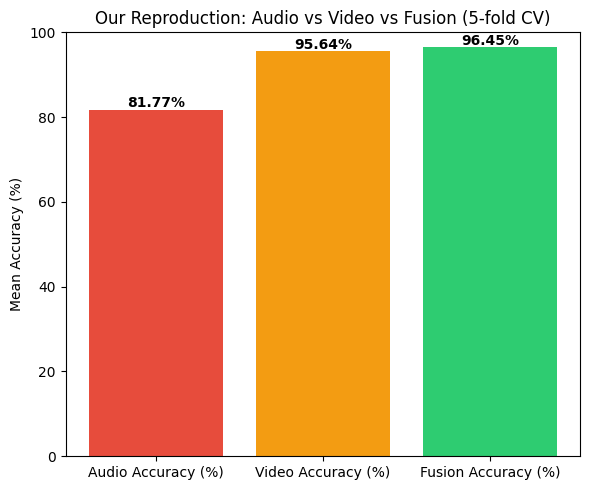

In [21]:

import matplotlib.pyplot as plt

means = table_vii.loc["Mean Accuracy"]
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(means.index, means.values, color=["#e74c3c", "#f39c12", "#2ecc71"])
for b, v in zip(bars, means.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.2f}%", ha="center", fontweight="bold")
ax.set_ylabel("Mean Accuracy (%)")
ax.set_title("Our Reproduction: Audio vs Video vs Fusion (5-fold CV)")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()


## 19. Save trained models

In [22]:

os.makedirs("/kaggle/working/models", exist_ok=True)
for i, m in enumerate(audio_models, 1):
    torch.save(m.state_dict(), f"/kaggle/working/models/audio_fold{i}.pt")
for i, m in enumerate(video_models, 1):
    torch.save(m.state_dict(), f"/kaggle/working/models/video_fold{i}.pt")
print("Saved audio + video fold models to /kaggle/working/models")


Saved audio + video fold models to /kaggle/working/models



## Notes on adapting this to your Kaggle run

- If GPU memory is tight, drop `video_batch` to 16 and/or reduce `n_frames` — the disk-caching means re-running is cheap after the first cache pass.
- `fusion_epochs=1000` with `EarlyStopper(patience=30)` in practice converges well before 1000 given the MLP's small size — don't be alarmed if it stops around epoch 150–400.
- Numbers above are **your own reproduction's** results, not guaranteed to hit the paper's exact 79.24/92.72/96.06% — that depends on your actual data split, hardware nondeterminism, and how closely the ambiguous details (fixed MFCC length, video refine-head shape handling, SMOTE granularity) line up with what the original authors did internally.


---

# Measured results

Loaded from `results/` — produced by the runs in `src/`, not by executing this notebook.
